In [7]:
import pickle
import pyBigWig

import json
import math
import h5py
import numpy as np
import pandas as pd
import pysam
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, pearsonr, spearmanr
from sklearn.metrics import mean_squared_error

In [8]:
PRED_H5 = "./chrombpnet_model/evaluation/chrombpnet_predictions.h5"
BAM = "sorted_H2.bam"

def decode_arr(arr):
    return np.array([
        x.decode("utf-8") if isinstance(x, (bytes, bytearray)) else str(x)
        for x in arr
    ])

def extract_atac_profile_tn5(bam, chrom, start, end):
    prof = np.zeros(end - start, dtype=np.float32)

    for read in bam.fetch(chrom, start, end):
        if read.is_unmapped or read.is_secondary or read.is_supplementary:
            continue
        if read.is_duplicate:
            continue
        if read.mapping_quality <= 0:
            continue

        if read.is_reverse:
            pos = read.reference_end - 5
        else:
            pos = read.reference_start + 4

        if start <= pos < end:
            prof[pos - start] += 1.0

    return prof

In [9]:
with h5py.File(PRED_H5, "r") as f:
    chrom = decode_arr(f["coords"]["coords_chrom"][:])
    h5_center = f["coords"]["coords_center"][:].astype(int)
    y_pred_counts = np.asarray(f["predictions"]["logcounts"][:]).reshape(-1)
    y_pred_profile_logits = f["predictions"]["profs"][:]

# correct the coordinate
center = h5_center + 1057

# output window is 1000 bp
window = y_pred_profile_logits.shape[1]   # should be 1000
assert window == 1000

y_test_profile_raw = np.zeros((len(chrom), window), dtype=np.float32)

with pysam.AlignmentFile(BAM, "rb") as bam:
    for i, (c, ct) in enumerate(zip(chrom, center)):
        start = int(ct) - 500
        end = int(ct) + 500
        y_test_profile_raw[i] = extract_atac_profile_tn5(bam, c, start, end)

raw_counts = y_test_profile_raw.sum(axis=1)
y_test_counts = np.log1p(raw_counts)
# -------------------------
#  quick metrics
# -------------------------
pear = pearsonr(y_test_counts, y_pred_counts)[0]
spear = spearmanr(y_test_counts, y_pred_counts)[0]
mse = mean_squared_error(y_test_counts, y_pred_counts)

print(f"Only peaks count: spearman R={spear:.3f}, Pearson R={pear:.3f}, mse={mse:.3f}")

Only peaks count: spearman R=0.611, Pearson R=0.671, mse=0.631


In [10]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Nimbus Sans"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

In [11]:
def plot_counts_scatter(
    y_test_counts,
    y_pred_counts,
    out_png="counts_pearsonr_like_attached.png",
    title="chrombpnet prediction",
    figsize=(8,8),
    point_size=15,
    label_fs=20,
    tick_fs=18,
    title_fs=18,
    text_fs=15,
    cbar_fs=15,
):
   
    x = np.asarray(y_test_counts).reshape(-1)
    y = np.asarray(y_pred_counts).reshape(-1)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    # metrics
    pear = pearsonr(x, y)[0]
    spear = spearmanr(x, y)[0]
    mse = mean_squared_error(x, y)

    # KDE density for point coloring
    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy)

    # plot low-density points first, high-density last
    order = np.argsort(z)
    x, y, z = x[order], y[order], z[order]

    # axis limits
    xy_min = min(x.min(), y.min())
    xy_max = max(x.max(), y.max())
    pad = 0.03 * (xy_max - xy_min + 1e-8)
    lims = [xy_min - pad, xy_max + pad]

    fig, ax = plt.subplots(figsize=figsize)

    sc = ax.scatter(
        x, y,
        c=z,
        s=point_size,
        cmap="viridis",
        edgecolors="none",
        rasterized=True
    )

    # diagonal y=x
    ax.plot(lims, lims, linestyle="--", linewidth=1)

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect("equal", adjustable="box")

    # labels
    ax.set_xlabel("Observed log counts", fontsize=label_fs)
    ax.set_ylabel("Predicted log counts", fontsize=label_fs)
    ax.set_title("Chrombpnet Prediction", fontsize=title_fs)

    # ticks
    ax.tick_params(axis='both', labelsize=tick_fs)

    # stats box
    ax.text(
        0.05, 0.95,
        f"spearman R={spear:.3f}\nPearson R={pear:.3f}\nmse={mse:.3f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=text_fs,
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="black")
    )

    # colorbar
    cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Density", fontsize=label_fs)
    cbar.ax.tick_params(labelsize=cbar_fs)

    plt.grid()
    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {out_png}")

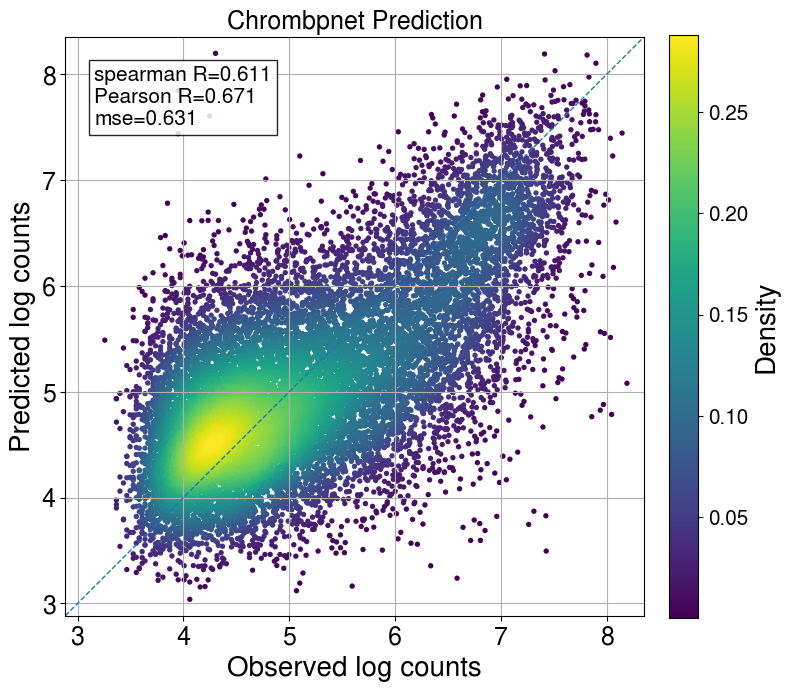

Saved: chrombpnet_atac.pdf


In [12]:
plot_counts_scatter(
    y_test_counts=y_test_counts,
    y_pred_counts=y_pred_counts,
    out_png="chrombpnet_atac.pdf",
    title=""
)

In [13]:
df = pd.DataFrame({'y_pred':y_pred_counts, "y_test":y_test_counts})

In [14]:
df

,y_pred,y_test
0,6.445047,6.006353
1,4.622994,5.187386
2,4.429083,5.043425
3,4.166654,4.941642
4,5.559110,5.627621
...,...,...
14028,4.010461,4.356709
14029,6.571970,7.308543
14030,4.227371,3.850148
14031,5.440042,4.158883


In [15]:
df.to_csv('chrombpnet_y_pred_y_test.csv', index=None)